# Time series 12: HAC + AR(1) (clustering then first-order autoregression)

Same **HAC clustering** as time_series_10 (Spearman correlation, complete linkage). Instead of LSTM per cluster, we fit a **first-order autoregression (AR(1))** per cluster: \(y_t = \phi \, y_{t-1} + c\) on the **cluster mean** series. Predictions are compared to the **naive** (persistence) baseline.

- **HAC**: Same as ts10 — channels grouped by correlation.
- **AR(1) per cluster**: One AR(1) per cluster fitted on the mean over channels in that cluster (training data). At test time, predict next value of the cluster mean and assign to all channels in the cluster.
- **Evaluation**: MAPE, RMSE, MAE; comparison and plots vs naive.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)
Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
T_total = Z.shape[0]

print(f"Loaded {len(df)} rows. Channels: {N}, Shape: (T={T_total}, N={N})")

Loaded 9192 rows. Channels: 70, Shape: (T=9192, N=70)


## Train / validation / test split (6 : 1 : 3) and optional low-pass filter

Same as time_series_10.

In [2]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

USE_LOWPASS = True
CUTOFF = 0.5
FILTER_ORDER = 3

def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
    from scipy.signal import butter, filtfilt
    normal_cutoff = min(float(cutoff), 0.99)
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    out = np.zeros_like(Z_mat)
    for j in range(Z_mat.shape[1]):
        out[:, j] = filtfilt(b, a, Z_mat[:, j])
    return out

if USE_LOWPASS:
    Z_full = lowpass_per_channel(Z, cutoff=CUTOFF, order=FILTER_ORDER)
    print(f"Applied low-pass filter (cutoff={CUTOFF}, order={FILTER_ORDER}).")
else:
    Z_full = Z.copy()

Z_train = Z_full[:n_train]
Z_val = Z_full[n_train : n_train + n_val]
Z_test = Z_full[n_train + n_val :]
test_start = n_train + n_val
print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Applied low-pass filter (cutoff=0.5, order=3).
Train: 5515, Val: 919, Test: 2758


## HAC (Spearman, complete linkage)

Same as time_series_10: distance = 1 − |Spearman|, complete linkage, cut at n_clusters.

In [3]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

print("Computing SRCC matrix on training data...")
rho, _ = spearmanr(Z_train, axis=0, nan_policy="omit")
rho = np.nan_to_num(rho, nan=0.0)
D = 1 - np.abs(rho)
np.fill_diagonal(D, 0)

D_cond = squareform(D, checks=False)
Z_link = linkage(D_cond, method="complete")
n_clusters = max(2, min(20, N // 4))
labels = fcluster(Z_link, n_clusters, criterion="maxclust")
labels = labels - 1
clusters = [np.where(labels == c)[0] for c in range(n_clusters)]
cluster_sizes = [len(c) for c in clusters]
print(f"HAC: {n_clusters} clusters. Sizes: {cluster_sizes}")

Computing SRCC matrix on training data...
HAC: 17 clusters. Sizes: [14, 2, 1, 1, 1, 1, 2, 2, 4, 8, 8, 5, 5, 11, 3, 1, 1]


## AR(1) per cluster

For each cluster, form the **mean** time series over its channels (on training data). Fit AR(1): \(y_t = \phi\, y_{t-1} + c\) by OLS. Store \((\phi_c, c_c)\) per cluster.

In [4]:
ar1_phi = {}
ar1_c = {}
for c in range(n_clusters):
    idx = clusters[c]
    # Cluster mean series (T_train,)
    mean_series = np.mean(Z_train[:, idx], axis=1)
    y = mean_series[1:]   # y_t
    x = mean_series[:-1] # y_{t-1}
    # OLS: y = phi * x + c  -> polyfit(x, y, 1) gives [phi, c]
    phi, c_val = np.polyfit(x, y, 1)
    ar1_phi[c] = float(phi)
    ar1_c[c] = float(c_val)
print(f"Fitted AR(1) for {n_clusters} clusters.")

Fitted AR(1) for 17 clusters.


## Test: rolling prediction with HAC-AR(1)

For each test step, compute cluster mean at t−1, predict next value with AR(1), assign to all channels in the cluster.

In [5]:
pred_test = np.full((n_test, N), np.nan, dtype=np.float64)
for t in range(n_test):
    global_idx = test_start + t
    prev_idx = global_idx - 1 if t > 0 else test_start - 1
    for c in range(n_clusters):
        idx = clusters[c]
        mean_prev = np.mean(Z_full[prev_idx, idx])
        pred_mean = ar1_phi[c] * mean_prev + ar1_c[c]
        pred_test[t, idx] = pred_mean

nan_mask = np.isnan(pred_test)
if np.any(nan_mask):
    for t in range(n_test):
        for j in range(N):
            if np.isnan(pred_test[t, j]):
                pred_test[t, j] = Z_full[test_start + t - 1, j] if t > 0 else Z_full[test_start - 1, j]

valid = ~np.isnan(pred_test)
mape = np.mean(np.abs((Z_test[valid] - pred_test[valid]) / (np.abs(Z_test[valid]) + 1e-8))) * 100
rmse = np.sqrt(np.mean((Z_test[valid] - pred_test[valid]) ** 2))
mae = np.mean(np.abs(Z_test[valid] - pred_test[valid]))

print("HAC-AR(1) (test set):")
print(f"  MAPE = {mape:.4f}%")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")

HAC-AR(1) (test set):
  MAPE = 21.2461%
  RMSE = 6.4201
  MAE  = 4.1238


## Naive baseline (persistence)

Predict next value = last observed value (same as in ts8–ts11).

In [6]:
pred_naive = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    pred_naive[t] = Z_full[test_start + t - 1] if t > 0 else Z_full[test_start - 1]

mape_naive = np.mean(np.abs((Z_test - pred_naive) / (np.abs(Z_test) + 1e-8))) * 100
rmse_naive = np.sqrt(np.mean((Z_test - pred_naive) ** 2))
mae_naive = np.mean(np.abs(Z_test - pred_naive))

print("Naive (last value repeated):")
print(f"  MAPE = {mape_naive:.4f}%, RMSE = {rmse_naive:.4f}, MAE = {mae_naive:.4f}")

Naive (last value repeated):
  MAPE = 13.0105%, RMSE = 4.5277, MAE = 2.7672


## Comparison and plots: HAC-AR(1) vs Naive

Summary metrics and MAE / MASE per test step.

Comparison: HAC-AR(1) vs Naive
  MAPE: HAC-AR(1) = 21.2461%,  Naive = 13.0105%
  RMSE: HAC-AR(1) = 6.4201,  Naive = 4.5277
  MAE:  HAC-AR(1) = 4.1238,  Naive = 2.7672


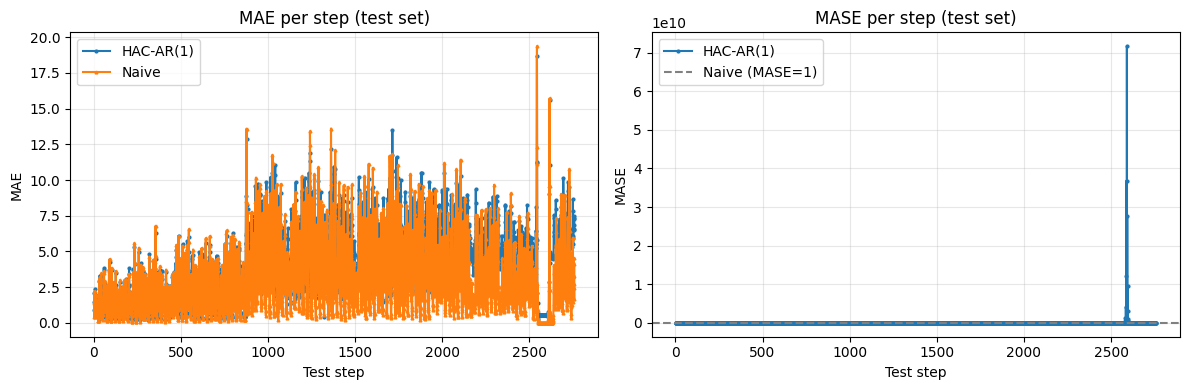

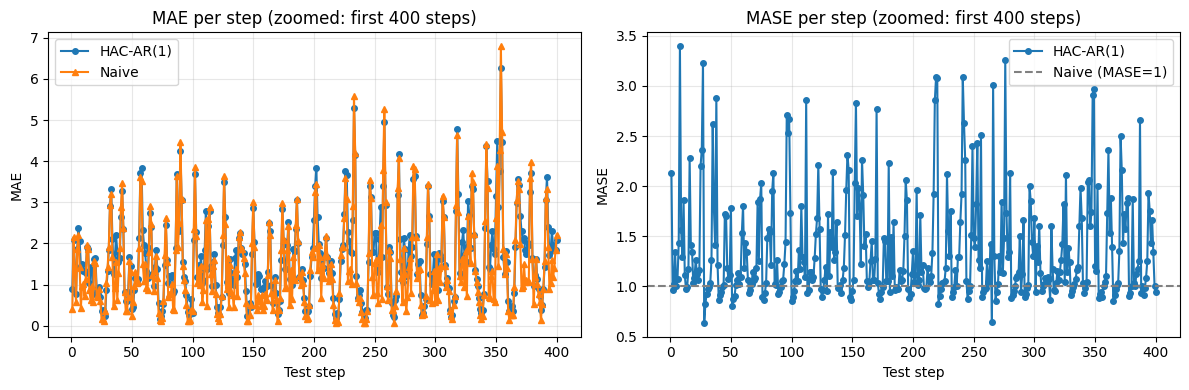

In [7]:
print("Comparison: HAC-AR(1) vs Naive")
print(f"  MAPE: HAC-AR(1) = {mape:.4f}%,  Naive = {mape_naive:.4f}%")
print(f"  RMSE: HAC-AR(1) = {rmse:.4f},  Naive = {rmse_naive:.4f}")
print(f"  MAE:  HAC-AR(1) = {mae:.4f},  Naive = {mae_naive:.4f}")

import matplotlib.pyplot as plt
maes_ar1 = [float(np.mean(np.abs(Z_test[t] - pred_test[t]))) for t in range(n_test)]
maes_naive_d = [float(np.mean(np.abs(Z_test[t] - pred_naive[t]))) for t in range(n_test)]
mase_ar1 = [maes_ar1[t] / (maes_naive_d[t] + 1e-12) for t in range(n_test)]
steps = list(range(1, n_test + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(steps, maes_ar1, "o-", label="HAC-AR(1)", markersize=2)
ax1.plot(steps, maes_naive_d, "^-", label="Naive", markersize=2)
ax1.set_xlabel("Test step")
ax1.set_ylabel("MAE")
ax1.set_title("MAE per step (test set)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(steps, mase_ar1, "o-", label="HAC-AR(1)", markersize=2)
ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax2.set_xlabel("Test step")
ax2.set_ylabel("MASE")
ax2.set_title("MASE per step (test set)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

zoom_steps = min(400, n_test)
steps_zoom = steps[:zoom_steps]
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.plot(steps_zoom, maes_ar1[:zoom_steps], "o-", label="HAC-AR(1)", markersize=4)
ax3.plot(steps_zoom, maes_naive_d[:zoom_steps], "^-", label="Naive", markersize=4)
ax3.set_xlabel("Test step")
ax3.set_ylabel("MAE")
ax3.set_title(f"MAE per step (zoomed: first {zoom_steps} steps)")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax4.plot(steps_zoom, mase_ar1[:zoom_steps], "o-", label="HAC-AR(1)", markersize=4)
ax4.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax4.set_xlabel("Test step")
ax4.set_ylabel("MASE")
ax4.set_title(f"MASE per step (zoomed: first {zoom_steps} steps)")
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()